# Clasificador binario de edad — menores (<18) vs adultos (>=18)

Reproducimos el formato de la **práctica de Deep Learning en radiología**, ejercicio
por ejercicio, pero aplicado a un problema distinto: clasificar imágenes de cara
como **menor** (<18) o **adulto** (>=18).

- **Etiqueta**: `1.0` = menor (<18) / `0.0` = adulto (>=18)
- **Score (BD)**: en `[0, 1]` = probabilidad de ser menor
- **Framework**: PyTorch (la práctica original usa Keras)
- **Modelo de transferencia**: ResNet-50 (la práctica usa MobileNetV2)

Vamos a entrenar **tres modelos** y compararlos:
1. CNN desde cero
2. ResNet-50 con transferencia de conocimiento
3. ResNet-50 con transferencia + augmentation


# 1

Genera los datasets de entrenamiento y validación y prepáralos para entrenar una CNN desde cero.


In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))
print(torch.cuda.is_available())

2.11.0+cu130
13.0
NVIDIA GeForce RTX 5080
(12, 0)
True


In [2]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split
from torchvision import models
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

DATASET_ROOT = "C:\\Users\\diego\\Documents\\dataset\\face_age"
PATH_MODELS  = "models"
BATCH_SIZE   = 32
EPOCHS       = 10
PATIENCE     = 5
LR           = 1e-4
IMG_SIZE     = (224, 224)

os.makedirs(PATH_MODELS, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


Dispositivo: cuda


Total imagenes : 9,778
Menores (<18)  : 3,925  (40.1%)
Adultos (>=18) : 5,853  (59.9%)


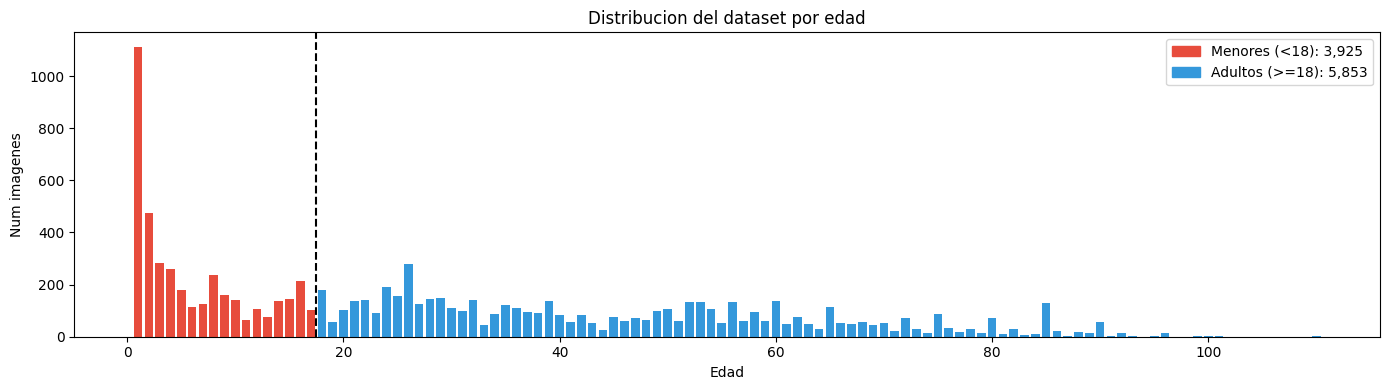

In [3]:
# Exploracion del dataset
ages, n_minors_per_age, n_adults_per_age = [], [], []
minor_total, adult_total = 0, 0

for folder in sorted(Path(DATASET_ROOT).iterdir()):
    if not folder.is_dir():
        continue
    try:
        age = int(folder.name)
    except ValueError:
        continue
    n = sum(len(list(folder.glob(ext))) for ext in ("*.png", "*.jpg", "*.jpeg"))
    ages.append(age)
    if age < 18:
        n_minors_per_age.append(n); n_adults_per_age.append(0)
        minor_total += n
    else:
        n_minors_per_age.append(0); n_adults_per_age.append(n)
        adult_total += n

total = minor_total + adult_total
print(f"Total imagenes : {total:,}")
print(f"Menores (<18)  : {minor_total:,}  ({100*minor_total/total:.1f}%)")
print(f"Adultos (>=18) : {adult_total:,}  ({100*adult_total/total:.1f}%)")

plt.figure(figsize=(14, 4))
counts = [m + a for m, a in zip(n_minors_per_age, n_adults_per_age)]
colors = ["#e74c3c" if a < 18 else "#3498db" for a in ages]
plt.bar(ages, counts, color=colors, width=0.8)
plt.axvline(x=17.5, color="black", linestyle="--", linewidth=1.5, label="Limite 18")
plt.xlabel("Edad"); plt.ylabel("Num imagenes")
plt.title("Distribucion del dataset por edad")
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color="#e74c3c", label=f"Menores (<18): {minor_total:,}"),
    plt.Rectangle((0,0),1,1, color="#3498db", label=f"Adultos (>=18): {adult_total:,}"),
], loc="upper right")
plt.tight_layout(); plt.show()


In [4]:
class FaceAgeDataset(Dataset):
    """Etiqueta binaria: 1.0 = menor (<18), 0.0 = adulto (>=18)"""
    def __init__(self, root, transform=None):
        self.samples  = []
        self.transform = transform
        for folder in sorted(Path(root).iterdir()):
            if not folder.is_dir(): continue
            try: age = int(folder.name)
            except ValueError: continue
            label = 1.0 if age < 18 else 0.0
            for ext in ("*.png", "*.jpg", "*.jpeg"):
                for img_path in folder.glob(ext):
                    self.samples.append((str(img_path), label))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.array(Image.open(path).convert("RGB"))
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, torch.tensor(label, dtype=torch.float32)


# Sin augmentation para los Ejercicios 1-6 (se introduce en el Ejercicio 7)
base_tf = A.Compose([
    A.Resize(*IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

full_ds    = FaceAgeDataset(DATASET_ROOT, transform=base_tf)
val_size   = int(len(full_ds) * 0.2)
train_size = len(full_ds) - val_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(42))

# WeightedRandomSampler para compensar desbalance
train_labels = [full_ds.samples[i][1] for i in train_ds.indices]
n_minor = int(sum(train_labels));  n_adult = len(train_labels) - n_minor
w_minor = (n_minor + n_adult) / (2 * n_minor) if n_minor > 0 else 1.0
w_adult = (n_minor + n_adult) / (2 * n_adult) if n_adult > 0 else 1.0
sample_w = [w_minor if l == 1.0 else w_adult for l in train_labels]
sampler  = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)

print(f"Train: {train_size:,}  Val: {val_size:,}")
print(f"Menores en train: {n_minor:,}  Adultos: {n_adult:,}")


Train: 7,823  Val: 1,955
Menores en train: 3,165  Adultos: 4,658


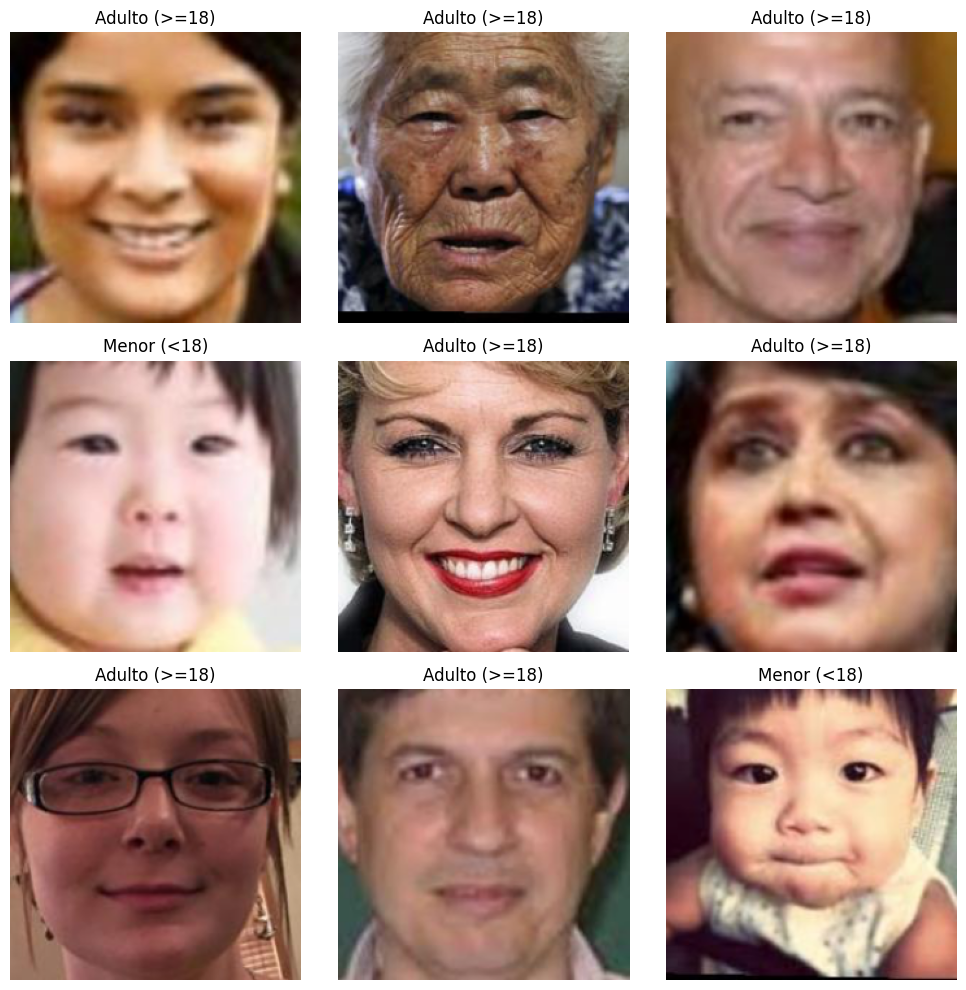

In [5]:
# Visualizacion de ejemplos del dataset (equivalente al class_names + plt.imshow de la practica)
class_names = ["Adulto (>=18)", "Menor (<18)"]
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(10, 10))
for i in range(9):
    img, label = full_ds[random.randint(0, len(full_ds) - 1)]
    img_show = img.numpy().transpose(1, 2, 0) * std + mean
    img_show = np.clip(img_show, 0, 1)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(img_show)
    plt.title(class_names[int(label)])
    plt.axis("off")
plt.tight_layout(); plt.show()


# 2

Implementa la siguiente arquitectura:

- Imagen de entrada de 224x224
- 4 capas convolucionales consecutivas con kernel 3x3, padding `same` y activación ReLU. Número de filtros: 32, 64, 128 y 256, respectivamente.
- 1 capa de agrupación máxima (MaxPool 2x2) que reduzca la imagen a la mitad
- Convierte la salida a un vector con `GlobalAveragePooling`
- Capa densa oculta de 32 neuronas + ReLU
- Capa de salida de 1 neurona (sin sigmoid: `BCEWithLogitsLoss` la aplica internamente)


In [ ]:
class CNNFromScratch(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(  3,  32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d( 32,  64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d( 64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.gap   = nn.AdaptiveAvgPool2d(1)
        self.fc1   = nn.Linear(256, 32)
        self.fc2   = nn.Linear( 32,  1)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool(x)
        x = self.gap(x).flatten(1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)


model_scratch = CNNFromScratch().to(device)

total     = sum(p.numel() for p in model_scratch.parameters())
trainable = sum(p.numel() for p in model_scratch.parameters() if p.requires_grad)
print(f"Parametros totales    : {total:,}")
print(f"Parametros entrenables: {trainable:,} ({100*trainable/total:.1f}%)")
print(model_scratch)


Parametros totales    : 396,673
Parametros entrenables: 396,673 (100.0%)
CNNFromScratch(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=256, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


# 3

Compila el modelo (`BCEWithLogitsLoss` + `Adam`) y entrénalo durante 10 épocas, incluyendo
**ModelCheckpoint** (guarda el mejor `val_accuracy`) y **EarlyStopping** (`patience=5`).


In [7]:
def binary_accuracy(logits, labels):
    preds = (torch.sigmoid(logits) > 0.5).float()
    return (preds == labels).float().mean().item()


def train_model(model, train_loader, val_loader, epochs, patience,
                lr, save_path, pos_weight_tensor=None):
    """Loop de entrenamiento + ModelCheckpoint (val_accuracy) + EarlyStopping (val_loss)."""
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history           = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc      = 0.0
    best_val_loss     = float("inf")
    epochs_no_improve = 0

    n_train = len(train_loader.dataset)
    n_val   = len(val_loader.dataset)

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        t_loss, t_acc = 0.0, 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs).squeeze(1)
            loss   = criterion(logits, labels)
            loss.backward(); optimizer.step()
            t_loss += loss.item() * len(imgs)
            t_acc  += binary_accuracy(logits.detach(), labels) * len(imgs)

        # Validacion
        model.eval()
        v_loss, v_acc = 0.0, 0.0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits = model(imgs).squeeze(1)
                v_loss += criterion(logits, labels).item() * len(imgs)
                v_acc  += binary_accuracy(logits, labels)  * len(imgs)

        train_loss = t_loss / n_train;  train_acc = t_acc / n_train
        val_loss   = v_loss / n_val;    val_acc   = v_acc / n_val
        scheduler.step()

        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc);   history["val_acc"].append(val_acc)

        print(f"Epoca {epoch:2d}/{epochs}  train loss: {train_loss:.4f}  acc: {train_acc:.3f}  |  "
              f"val loss: {val_loss:.4f}  acc: {val_acc:.3f}")

        # ModelCheckpoint — guarda si mejora val_accuracy
        if val_acc > best_val_acc or (val_acc == best_val_acc and val_loss < best_val_loss):
            best_val_acc = val_acc; best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"  -> Mejor modelo guardado (val acc={val_acc:.4f}  loss={val_loss:.4f})")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # EarlyStopping
        if epochs_no_improve >= patience:
            print(f"Early stopping en epoca {epoch} (sin mejora en {patience} epocas).")
            break

    print(f"Mejor val accuracy: {best_val_acc:.4f}  |  Modelo: {save_path}")
    return history, best_val_acc


# Peso para la clase minoritaria (se reutiliza en los 3 entrenamientos)
pos_weight = torch.tensor([n_adult / n_minor], dtype=torch.float32).to(device)

history_scratch, acc_scratch = train_model(
    model_scratch, train_loader, val_loader,
    epochs=EPOCHS, patience=PATIENCE, lr=LR,
    save_path=os.path.join(PATH_MODELS, "age_scratch.pth"),
    pos_weight_tensor=pos_weight,
)


Epoca  1/10  train loss: 0.7790  acc: 0.588  |  val loss: 0.7769  acc: 0.589
  -> Mejor modelo guardado (val acc=0.5887  loss=0.7769)
Epoca  2/10  train loss: 0.7596  acc: 0.621  |  val loss: 0.7969  acc: 0.513
Epoca  3/10  train loss: 0.7556  acc: 0.623  |  val loss: 0.7476  acc: 0.643
  -> Mejor modelo guardado (val acc=0.6435  loss=0.7476)
Epoca  4/10  train loss: 0.7542  acc: 0.634  |  val loss: 0.7584  acc: 0.620
Epoca  5/10  train loss: 0.7458  acc: 0.651  |  val loss: 0.7520  acc: 0.624
Epoca  6/10  train loss: 0.7399  acc: 0.654  |  val loss: 0.8058  acc: 0.561
Epoca  7/10  train loss: 0.7476  acc: 0.640  |  val loss: 0.7411  acc: 0.651
  -> Mejor modelo guardado (val acc=0.6512  loss=0.7411)
Epoca  8/10  train loss: 0.7352  acc: 0.652  |  val loss: 0.7383  acc: 0.661
  -> Mejor modelo guardado (val acc=0.6614  loss=0.7383)
Epoca  9/10  train loss: 0.7191  acc: 0.675  |  val loss: 0.7224  acc: 0.684
  -> Mejor modelo guardado (val acc=0.6844  loss=0.7224)
Epoca 10/10  train los

# 4

Muestra dos gráficas: pérdidas (train/val) y exactitud (train/val) del modelo del Ejercicio 3.


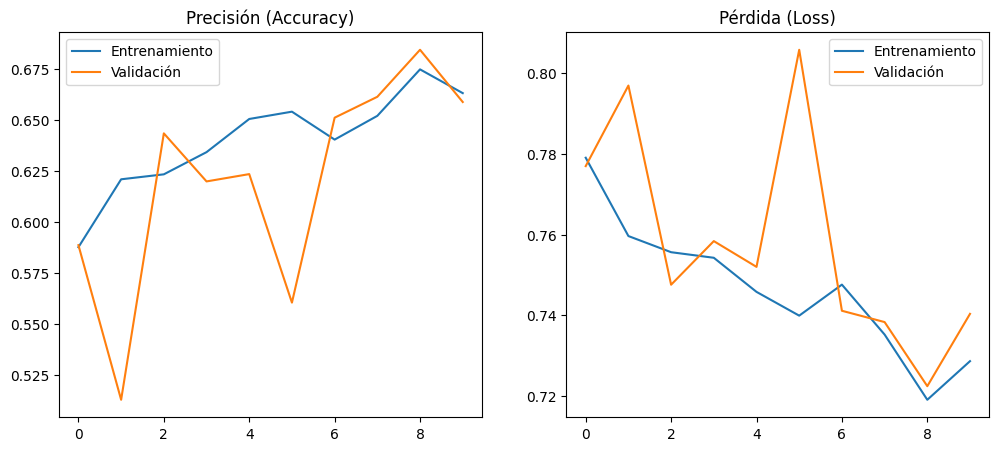

In [16]:
def plot_history(history, titulo=""):
    acc = history["train_acc"]
    val_acc = history["val_acc"]
    loss = history["train_loss"]
    val_loss = history["val_loss"]
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Entrenamiento")
    plt.plot(epochs_range, val_acc, label="Validación")
    plt.ylim(0, 1)
    plt.title("Precisión (Accuracy)")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Entrenamiento")
    plt.plot(epochs_range, val_loss, label="Validación")
    plt.ylim(0, 1)
    plt.title("Pérdida (Loss)")
    plt.legend()

    plt.show()


plot_history(history_scratch, "(CNN desde cero)")


# 5

Ahora vamos a entrenar de nuevo el modelo empleando **transferencia de conocimiento**.
La práctica de radiología usa MobileNetV2; aquí usamos **ResNet-50** preentrenado en
ImageNet (mejor desempeño en imágenes de caras).

- Congela toda la base
- Descongela solo `layer4` (último bloque residual) para fine-tuning
- Cabeza de clasificación: `Linear(2048, 256) → ReLU → Dropout(0.3) → Linear(256, 1)`


In [9]:
def get_resnet_model():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1),
    )
    return model.to(device)


model_transfer = get_resnet_model()

total     = sum(p.numel() for p in model_transfer.parameters())
trainable = sum(p.numel() for p in model_transfer.parameters() if p.requires_grad)
print(f"Parametros totales    : {total:,}")
print(f"Parametros entrenables: {trainable:,} ({100*trainable/total:.1f}%)")

history_transfer, acc_transfer = train_model(
    model_transfer, train_loader, val_loader,
    epochs=EPOCHS, patience=PATIENCE, lr=LR,
    save_path=os.path.join(PATH_MODELS, "age_transfer.pth"),
    pos_weight_tensor=pos_weight,
)


1.5%

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\diego/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


Parametros totales    : 24,032,833
Parametros entrenables: 15,489,537 (64.5%)
Epoca  1/10  train loss: 0.3378  acc: 0.863  |  val loss: 0.2422  acc: 0.919
  -> Mejor modelo guardado (val acc=0.9192  loss=0.2422)
Epoca  2/10  train loss: 0.1324  acc: 0.960  |  val loss: 0.2455  acc: 0.927
  -> Mejor modelo guardado (val acc=0.9269  loss=0.2455)
Epoca  3/10  train loss: 0.0608  acc: 0.984  |  val loss: 0.2485  acc: 0.926
Epoca  4/10  train loss: 0.0440  acc: 0.990  |  val loss: 0.2112  acc: 0.942
  -> Mejor modelo guardado (val acc=0.9422  loss=0.2112)
Epoca  5/10  train loss: 0.0235  acc: 0.993  |  val loss: 0.2479  acc: 0.935
Epoca  6/10  train loss: 0.0122  acc: 0.997  |  val loss: 0.2923  acc: 0.935
Epoca  7/10  train loss: 0.0083  acc: 0.998  |  val loss: 0.2754  acc: 0.940
Epoca  8/10  train loss: 0.0065  acc: 0.998  |  val loss: 0.2744  acc: 0.939
Epoca  9/10  train loss: 0.0062  acc: 0.999  |  val loss: 0.2895  acc: 0.939
Early stopping en epoca 9 (sin mejora en 5 epocas).
Mejor 

# 6

Muestra 3 gráficas:
- Curvas de pérdida (entrenamiento y validación) del modelo del Ejercicio 5
- Curvas de exactitud (entrenamiento y validación) del modelo del Ejercicio 5
- Curvas de exactitud en validación del Ejercicio 3 vs Ejercicio 5

¿Qué solución ofrece mejores resultados?


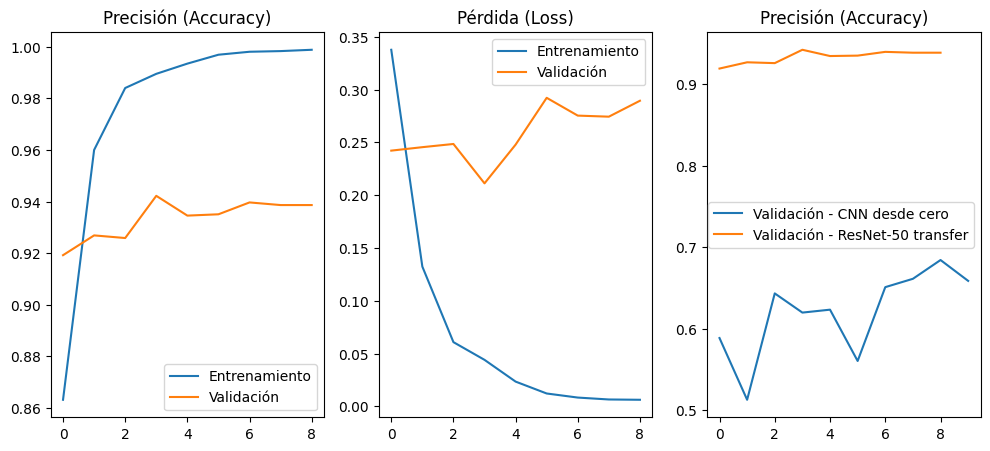

Mejor val accuracy — CNN desde cero  : 0.6844
Mejor val accuracy — ResNet-50 (TL)  : 0.9422


In [17]:
def plot_compare(h1, h2, n1="Modelo 1", n2="Modelo 2"):
    acc1 = h2["train_acc"]
    val_acc1 = h2["val_acc"]
    loss1 = h2["train_loss"]
    val_loss1 = h2["val_loss"]
    epochs_range1 = range(len(acc1))

    val_acc2 = h1["val_acc"]
    epochs_range2 = range(len(val_acc2))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_range1, acc1, label="Entrenamiento")
    plt.plot(epochs_range1, val_acc1, label="Validación")
    plt.ylim(0, 1)
    plt.title("Precisión (Accuracy)")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range1, loss1, label="Entrenamiento")
    plt.plot(epochs_range1, val_loss1, label="Validación")
    plt.ylim(0, 1)
    plt.title("Pérdida (Loss)")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs_range2, val_acc2, label=f"Validación - {n1}")
    plt.plot(epochs_range1, val_acc1, label=f"Validación - {n2}")
    plt.ylim(0, 1)
    plt.title("Precisión (Accuracy)")
    plt.legend()

    plt.show()


plot_compare(history_scratch, history_transfer, "CNN desde cero", "ResNet-50 transfer")
print(f"Mejor val accuracy — CNN desde cero  : {acc_scratch:.4f}")
print(f"Mejor val accuracy — ResNet-50 (TL)  : {acc_transfer:.4f}")


# 7

Ahora vamos a entrenar de nuevo el modelo introduciendo **aumento de datos**:

- Cambios de brillo y contraste aleatorio, con un 50% de probabilidad
- Uso del filtro CLAHE, con un 20% de probabilidad
- Rotaciones aleatorias, con un máximo de 10° y una probabilidad del 30%
- Giros horizontales con un 10% de probabilidad

Seguimos con la estrategia de transferencia de conocimiento (ResNet-50), que es la
que mejores resultados nos ha ofrecido en el Ejercicio 6.

¿Qué efecto tiene? ¿Mejoran los resultados?


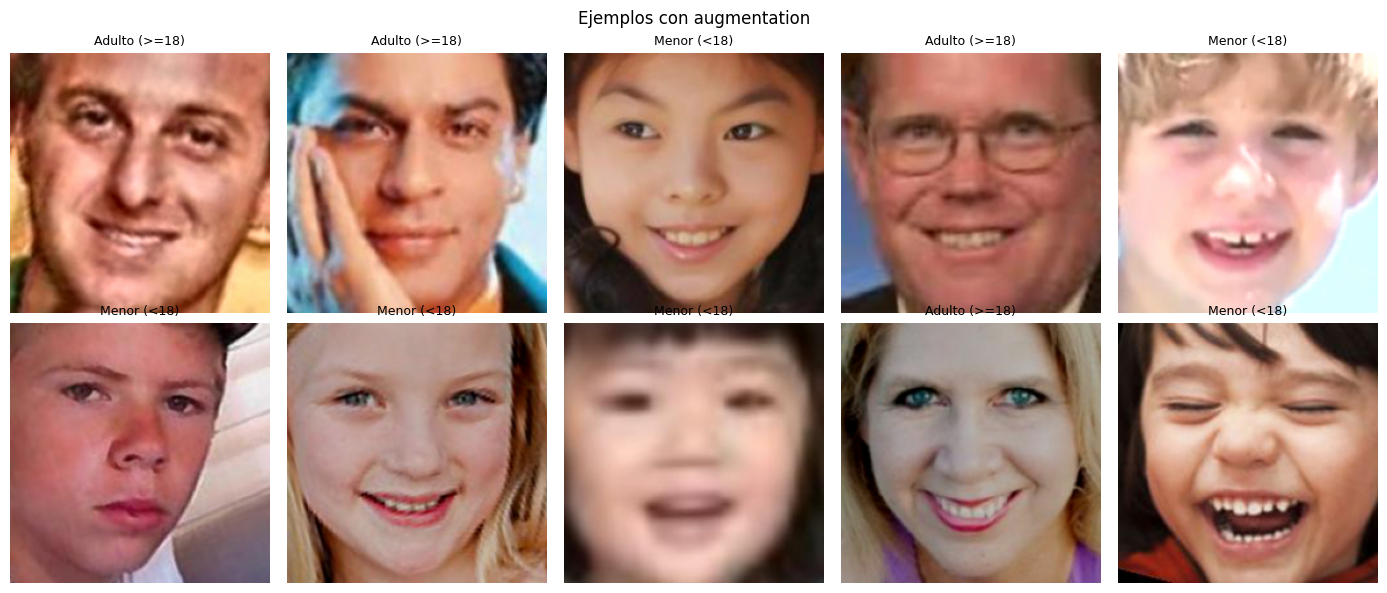

In [18]:
train_tf_aug = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.CLAHE(p=0.2),
    A.Rotate(limit=10, p=0.3),
    A.HorizontalFlip(p=0.1),
    A.Resize(*IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Nuevo dataset con aug en train; val no cambia
full_ds_aug         = FaceAgeDataset(DATASET_ROOT, transform=train_tf_aug)
train_ds_aug, _     = random_split(full_ds_aug, [train_size, val_size],
                                    generator=torch.Generator().manual_seed(42))
train_loader_aug    = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)

# Visualizamos algunas imagenes con augmentation
plt.figure(figsize=(14, 6))
for i in range(10):
    img, label = train_ds_aug[random.randint(0, len(train_ds_aug) - 1)]
    img_show = img.numpy().transpose(1, 2, 0) * std + mean
    img_show = np.clip(img_show, 0, 1)
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(img_show)
    plt.title(class_names[int(label)], fontsize=9)
    plt.axis("off")
plt.suptitle("Ejemplos con augmentation")
plt.tight_layout(); plt.show()


Epoca  1/10  train loss: 0.3722  acc: 0.854  |  val loss: 0.2605  acc: 0.918
  -> Mejor modelo guardado (val acc=0.9182  loss=0.2605)
Epoca  2/10  train loss: 0.2091  acc: 0.931  |  val loss: 0.2137  acc: 0.930
  -> Mejor modelo guardado (val acc=0.9304  loss=0.2137)
Epoca  3/10  train loss: 0.1592  acc: 0.947  |  val loss: 0.1992  acc: 0.941
  -> Mejor modelo guardado (val acc=0.9412  loss=0.1992)
Epoca  4/10  train loss: 0.1191  acc: 0.964  |  val loss: 0.2065  acc: 0.940
Epoca  5/10  train loss: 0.0952  acc: 0.970  |  val loss: 0.2150  acc: 0.944
  -> Mejor modelo guardado (val acc=0.9442  loss=0.2150)
Epoca  6/10  train loss: 0.0839  acc: 0.975  |  val loss: 0.2045  acc: 0.939
Epoca  7/10  train loss: 0.0650  acc: 0.981  |  val loss: 0.1904  acc: 0.943
Epoca  8/10  train loss: 0.0630  acc: 0.981  |  val loss: 0.2002  acc: 0.947
  -> Mejor modelo guardado (val acc=0.9468  loss=0.2002)
Epoca  9/10  train loss: 0.0571  acc: 0.982  |  val loss: 0.2110  acc: 0.944
Epoca 10/10  train los

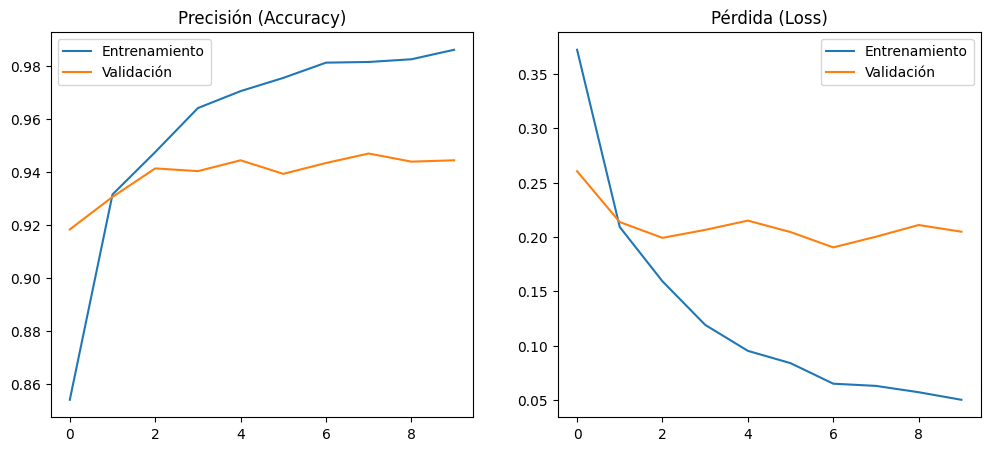


=== Comparativa final ===
CNN desde cero          : 0.6844
ResNet-50 transferencia : 0.9422
ResNet-50 + augmentation: 0.9468


In [ ]:
# Entrenamiento con augmentation (ResNet-50, mismo enfoque que el Ejercicio 5)
model_aug = get_resnet_model()

history_aug, acc_aug = train_model(
    model_aug, train_loader_aug, val_loader,
    epochs=EPOCHS, patience=PATIENCE, lr=LR,
    save_path=os.path.join(PATH_MODELS, "age_aug.pth"),
    pos_weight_tensor=pos_weight,
)

plot_history(history_aug, "(ResNet-50 + augmentation)")

print()
print("=== Comparativa final ===")
print(f"CNN desde cero          : {acc_scratch:.4f}")
print(f"ResNet-50 transferencia : {acc_transfer:.4f}")
print(f"ResNet-50 + augmentation: {acc_aug:.4f}")


# 8

Una vez realizados los entrenamientos anteriores, prepara un método en el que, dada
una nueva imagen de cara, con el mejor modelo seleccionado, prediga si es **menor (<18)**
o **adulto (>=18)** e imprima por pantalla la clase predicha y su probabilidad.

También evaluamos el modelo final sobre el conjunto de validación con matriz de
confusión, classification report y AUC-ROC.


In [13]:
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report
import seaborn as sns

# Cargamos el mejor modelo (segun val_accuracy entre los tres)
mejores = {
    "scratch":  (acc_scratch,  CNNFromScratch,    os.path.join(PATH_MODELS, "age_scratch.pth")),
    "transfer": (acc_transfer, get_resnet_model,  os.path.join(PATH_MODELS, "age_transfer.pth")),
    "aug":      (acc_aug,      get_resnet_model,  os.path.join(PATH_MODELS, "age_aug.pth")),
}
nombre_mejor = max(mejores, key=lambda k: mejores[k][0])
acc_best, build_fn, path_best = mejores[nombre_mejor]
print(f"Mejor modelo: {nombre_mejor} (val acc={acc_best:.4f})  -> {path_best}")

best_model = build_fn().to(device) if nombre_mejor == "scratch" else build_fn()
best_model.load_state_dict(torch.load(path_best, map_location=device))
best_model.eval()

# Tambien lo guardamos como age_model.pth para que lo use el servicio DE
final_path = "age_model.pth"
torch.save(best_model.state_dict(), final_path)
print(f"Modelo final copiado a: {final_path}")


Mejor modelo: aug (val acc=0.9453)  -> models\age_aug.pth
Modelo final copiado a: age_model.pth


Accuracy : 0.9453
AUC-ROC  : 0.9873

               precision    recall  f1-score   support

Adulto (>=18)       0.95      0.96      0.96      1195
  Menor (<18)       0.94      0.92      0.93       760

     accuracy                           0.95      1955
    macro avg       0.94      0.94      0.94      1955
 weighted avg       0.95      0.95      0.95      1955



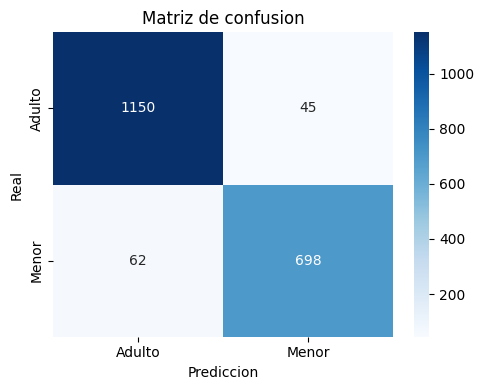

In [14]:
# Evaluacion sobre el conjunto de validacion
all_scores, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        logits  = best_model(imgs.to(device)).squeeze(1)
        scores  = torch.sigmoid(logits).cpu().numpy()
        all_scores.extend(scores)
        all_labels.extend(labels.numpy())

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)
all_preds  = (all_scores > 0.5).astype(float)

acc = (all_preds == all_labels).mean()
auc = roc_auc_score(all_labels, all_scores)
print(f"Accuracy : {acc:.4f}")
print(f"AUC-ROC  : {auc:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=["Adulto (>=18)", "Menor (<18)"]))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Adulto", "Menor"],
            yticklabels=["Adulto", "Menor"])
plt.title("Matriz de confusion")
plt.ylabel("Real"); plt.xlabel("Prediccion")
plt.tight_layout(); plt.show()


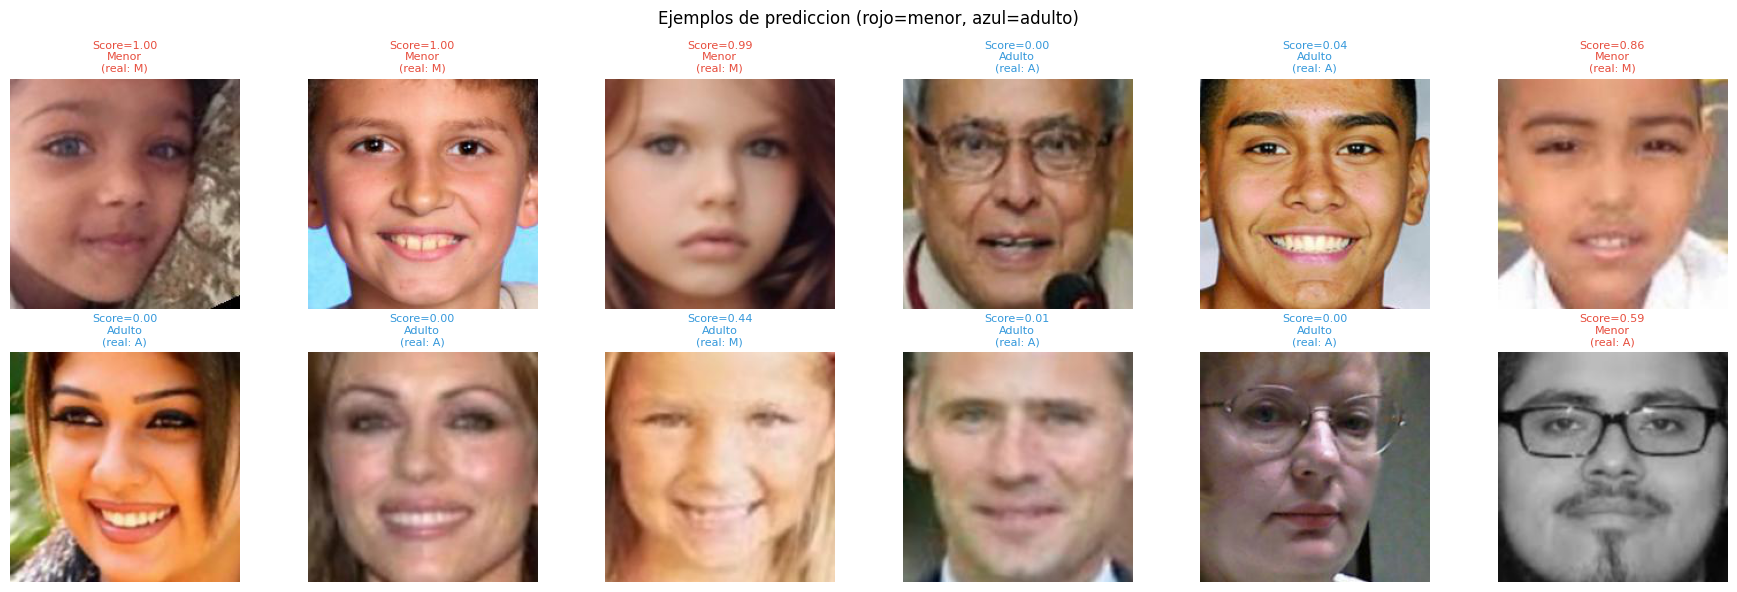

In [15]:
from torchvision import transforms as T

infer_tf = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def predecir(img_path: str) -> tuple:
    """Devuelve (score, es_menor) dado el path de una imagen de cara.

    score   : probabilidad en [0, 1] de ser menor (<18)
    es_menor: True si score > 0.5
    """
    img    = Image.open(img_path).convert("RGB")
    tensor = infer_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logit = best_model(tensor).squeeze().item()
    score    = torch.sigmoid(torch.tensor(logit)).item()
    es_menor = score > 0.5
    return round(score, 4), es_menor


# Ejemplo: 12 imagenes aleatorias de validacion con su prediccion
sample_indices = random.sample(range(len(val_ds)), 12)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for ax, idx in zip(axes.flat, sample_indices):
    path, true_label = full_ds.samples[val_ds.indices[idx]]
    img             = Image.open(path).convert("RGB")
    score, es_menor = predecir(path)
    color  = "#e74c3c" if es_menor else "#3498db"
    titulo = f"Score={score:.2f}\n{'Menor' if es_menor else 'Adulto'}\n(real: {'M' if true_label==1 else 'A'})"
    ax.imshow(img)
    ax.set_title(titulo, fontsize=8, color=color)
    ax.axis("off")
plt.suptitle("Ejemplos de prediccion (rojo=menor, azul=adulto)", fontsize=12)
plt.tight_layout(); plt.show()
